## Cohort Analysis – Introduction

## What is Cohort Analysis?
Cohort Analysis is a method of analyzing groups of users (called **cohorts**) who share a common characteristic within a defined time period.

A **cohort** is simply:
- A group of users who started something at the same time  

Cohort analysis helps us study how these users behave **over time**.

---

## Why Do We Use Cohort Analysis?
Cohort analysis allows us to:

1. Understand **retention** (how long users stay active)
2. Measure **churn** (how many users leave)
3. Compare **user quality across months**, countries, campaigns
4. Track **revenue growth**, **LTV**, and **engagement**
5. Identify **which month or campaign brought the best users**

Instead of looking at all users together, cohorts help you see **hidden patterns**.

---

## Basic Structure of Cohort Analysis
Every cohort analysis has 3 main components:

### 1 **Cohort Date / Cohort Month**
This is the date when the user first performed an action:
- First signup  
- First purchase  
- First login  
- First app install  

Example:  
User A signed up on 2024-01-10 → cohort month = **Jan 2024**

---

### 2 **Event Period**
This is the time difference between:
- The cohort start date  
- The activity date  

Example:  
If user signed up in **Jan 2024** but purchased again in **March 2024**,  
then **Event Period = Month 2**.

---

### 3 **Metric**
What you want to measure:
- Number of active users  
- Retention (%)  
- Revenue / LTV  
- Number of purchases  
- Sessions / activity count  

---
## What You Will Build in This Notebook
1. Load dataset  
2. Clean & prepare data  
3. Create cohort groups  
4. Calculate cohort periods  
5. Build retention matrix  
6. Visualize cohort heatmaps & retention curves  

This is the standard workflow for any cohort analysis project.



---
## Importing Libraries


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

## Data Loading & Cleaning

In [21]:
df=pd.read_excel("/content/KPMG_VI_New_raw_data_update_final.xlsx",sheet_name="Transactions",skiprows=1)
df.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361.0
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145.0
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226.0


In [22]:
df.shape

(20000, 13)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           20000 non-null  int64         
 1   product_id               20000 non-null  int64         
 2   customer_id              20000 non-null  int64         
 3   transaction_date         20000 non-null  datetime64[ns]
 4   online_order             19640 non-null  float64       
 5   order_status             20000 non-null  object        
 6   brand                    19803 non-null  object        
 7   product_line             19803 non-null  object        
 8   product_class            19803 non-null  object        
 9   product_size             19803 non-null  object        
 10  list_price               20000 non-null  float64       
 11  standard_cost            19803 non-null  float64       
 12  product_first_sold_date  19803 n

**Visulize Misssing Values**

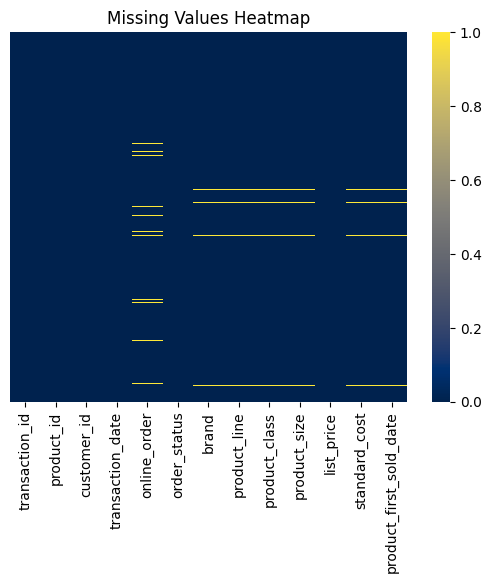

In [24]:
sns.heatmap(df.isnull(),cbar=True,cmap="cividis",yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

We expect 20,000 records in each column, but some columns
`(like online_order, brand, product_line, product_class) `
contain missing values.
---



In [25]:
#Replace blank spaces (" ") with NaN
df = df.replace(" ", np.nan)

In [29]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

In [31]:
df.isnull().sum().sum()

np.int64(0)

* Replaces blank strings " " with nan

* Fills numeric columns using mean

* Fills text/categorical columns using most frequent value



---



### Assigning Cohorts & Creating Monthly Offset

To group customers into monthly cohorts, we first convert every transaction date into the **first day of its month**. This gives us a consistent monthly timeframe for analysis.

- We create a small function that takes any date and returns the **1st day of that month**.
- Then we apply this function to the transaction date column.
- The result is a new column called **TransactionMonth**, which represents the month each transaction belongs to.

In [33]:
def get_month(mon):
  return dt.datetime(mon.year,mon.month,1)

In [34]:
df['TransactionMonth']=df['transaction_date'].apply(get_month)

**Assigning Cohort Month (First Month of Customer Activity)**

To identify when each customer first became active, we group the data by customer ID and look at the earliest month in which they made a transaction.

- First, we group all records by `customer_id` and focus on their `TransactionMonth`.
- Then we assign each customer’s **first ever transaction month** back to the dataset as a new column called `CohortMonth`.

This `CohortMonth` represents the month a customer joined or made their first purchase, and it is the foundation for building monthly cohorts in our analysis.


In [37]:
df['CohortMonth']=df.groupby("customer_id")['TransactionMonth'].transform('min')

In [39]:
df.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,TransactionMonth,CohortMonth
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0,2017-02-01,2017-02-01
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0,2017-05-01,2017-01-01
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361.0,2017-10-01,2017-01-01
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145.0,2017-08-01,2017-02-01
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226.0,2017-10-01,2017-01-01


### Calculating  (Cohort Index)

To compare customer behavior across cohorts, we need to know how many months have passed between a transaction and the customer’s first activity month. This is called the **cohort index**.

To calculate it:

- We first ensure both `TransactionMonth` and `CohortMonth` are in proper datetime format.
- Then we measure the difference in years and months between the two dates.
- Finally, we convert this difference into a single number that represents the month number in the customer’s lifecycle (Month 1, Month 2, Month 3, etc.).


In [40]:
df['TransactionMonth']=pd.to_datetime(df['TransactionMonth'])
df['CohortMonth']=pd.to_datetime(df['CohortMonth'])

In [41]:
df['CohortIndex']=(df['TransactionMonth'].dt.year-df['CohortMonth'].dt.year)*12+(df['TransactionMonth'].dt.month-df['CohortMonth'].dt.month)+1

In [42]:
df.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,TransactionMonth,CohortMonth,CohortIndex
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0,2017-02-01,2017-02-01,1
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0,2017-05-01,2017-01-01,5
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361.0,2017-10-01,2017-01-01,10
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145.0,2017-08-01,2017-02-01,7
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226.0,2017-10-01,2017-01-01,10


### Building the Cohort Table (Counting Unique Active Users)

To understand how many customers remain active in each month of their lifecycle, we create a cohort table using CohortMonth and CohortIndex.

- First, we group the data by both `CohortMonth` (when the customer joined) and `CohortIndex` (how many months since they joined).
- From each group, we count the number of unique customers. This gives us the number of active users for every cohort in every month.


In [51]:
cohort_df=df.groupby(['CohortMonth','CohortIndex'])['customer_id'].nunique().reset_index()

In [53]:
cohort_df.rename(columns={'customer_id':'Customers_Count'},inplace=True)

In [54]:
cohort_df

,CohortMonth,CohortIndex,Customers_Count
0,2017-01-01,1,1354
1,2017-01-01,2,486
2,2017-01-01,3,508
3,2017-01-01,4,509
4,2017-01-01,5,502
...,...,...,...
73,2017-10-01,2,6
74,2017-10-01,3,8
75,2017-11-01,1,13
76,2017-11-01,2,5


In [56]:
cohort_table=cohort_df.pivot(index='CohortMonth',columns='CohortIndex',values='Customers_Count')
cohort_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2017-01-01,1354.0,486.0,508.0,509.0,502.0,483.0,518.0,529.0,500.0,531.0,497.0,516.0
2017-02-01,800.0,325.0,298.0,313.0,288.0,298.0,308.0,281.0,329.0,308.0,296.0,NaN
2017-03-01,484.0,167.0,174.0,167.0,182.0,184.0,172.0,212.0,189.0,181.0,NaN,NaN
2017-04-01,336.0,111.0,121.0,153.0,143.0,121.0,142.0,126.0,132.0,NaN,NaN,NaN
2017-05-01,210.0,85.0,81.0,87.0,71.0,74.0,73.0,81.0,NaN,NaN,NaN,NaN
2017-06-01,122.0,45.0,44.0,47.0,46.0,46.0,53.0,NaN,NaN,NaN,NaN,NaN
2017-07-01,77.0,26.0,29.0,32.0,37.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,51.0,19.0,21.0,17.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,23.0,7.0,7.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Finally, we create a pivot table where:
  - **Rows** represent CohortMonth,
  - **Columns** represent CohortIndex,
  - **Values** show the count of unique customers.

This pivot table becomes our cohort matrix, which helps visualize retention patterns over time.

Here:

Each row is a cohort (month when customers first purchased).

Each column (1, 2, 3, …) is how many months since that cohort started.

The numbers (Customer Count) are unique users active in that period.

---



### 📌 Calculating Retention Rates

To measure retention, we convert the raw cohort counts into **percentages**:

- First, we take the size of each cohort (number of users in their first month) from the first column of the cohort table.
- Then, we divide all values in the cohort table by the cohort size.  
  This gives us the **retention rate** for each month of the cohort’s lifecycle.
- The resulting `retention_table` shows the **percentage of users still active** each month, making it easy to compare cohorts of different sizes.


In [64]:
cohort_size=cohort_table.iloc[:,0]
retention_table=cohort_table.divide(cohort_size,axis=0)

In [68]:
retention_table.round(4)*100

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2017-01-01,100.0,35.89,37.52,37.59,37.08,35.67,38.26,39.07,36.93,39.22,36.71,38.11
2017-02-01,100.0,40.62,37.25,39.12,36.00,37.25,38.50,35.12,41.12,38.50,37.00,NaN
2017-03-01,100.0,34.50,35.95,34.50,37.60,38.02,35.54,43.80,39.05,37.40,NaN,NaN
2017-04-01,100.0,33.04,36.01,45.54,42.56,36.01,42.26,37.50,39.29,NaN,NaN,NaN
2017-05-01,100.0,40.48,38.57,41.43,33.81,35.24,34.76,38.57,NaN,NaN,NaN,NaN
2017-06-01,100.0,36.89,36.07,38.52,37.70,37.70,43.44,NaN,NaN,NaN,NaN,NaN
2017-07-01,100.0,33.77,37.66,41.56,48.05,31.17,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,100.0,37.25,41.18,33.33,25.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,100.0,30.43,30.43,39.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
retention_table.index=retention_table.index.strftime("%B %Y")

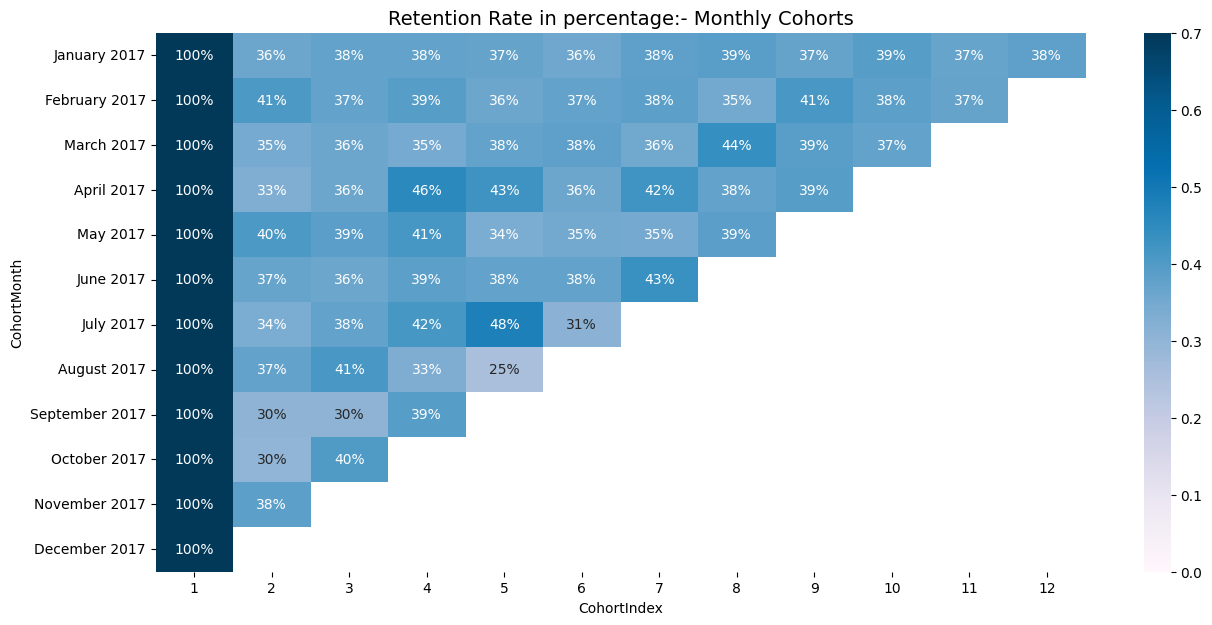

In [79]:
plt.figure(figsize=(15,7))
sns.heatmap(retention_table,fmt=".0%",cmap='PuBu',annot=True,vmin = 0.0 , vmax = 0.7)
plt.title('Retention Rate in percentage:- Monthly Cohorts', fontsize = 14)
plt.show()

### the Cohort Retention Heatmap

The heatmap shows **monthly retention rates** for each cohort of customers:

- **Rows** = CohortMonth (month when the customer made their first purchase)
- **Columns** = CohortIndex (months since first purchase)
- **Cell values** = Retention rate (% of users still active)

**Key observations:**

1. The first column of each row is always **100%**, because it represents the cohort’s first month.
2. Retention generally **declines over time**:
   - For example, January 2017 cohort starts at 100% in month 1, drops to ~36% in month 2, and fluctuates around 37–39% in later months.
3. Some cohorts show **higher retention in later months** (e.g., April 2017 month 4 = 46%), indicating strong engagement for that period.
4. Recent cohorts (e.g., October–December 2017) have fewer months of data, so retention appears only for the first few months.

**Insights:**

- Overall, **retention decreases over time**, which is common in most businesses.
- Some months have better retention than others, possibly due to **seasonal effects, promotions, or marketing campaigns**.
- The heatmap helps identify **which cohorts are most engaged** and where interventions may be needed to improve retention.





---



---


**Z.I. Turjo**